In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torchvision
from pylab import *
from dataclasses import dataclass
import math
import matplotlib as mpl

from src.utils import *

%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import matplotlib.patches as mpatches
import copy
import json

import pylab as plt
plt.rc('text', usetex=True)
plt.rc('font', size=15,family='serif')
# plt.style.use('matplotlibrc')
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FormatStrFormatter
# plt.style.use('tableau-colorblind10')

%matplotlib inline

np.set_printoptions(linewidth=1000)

receptor_labels = np.loadtxt("DoOR_datasets/receptor_labels.txt", dtype='str', delimiter=',')
odorant_labels = np.genfromtxt("DoOR_datasets/odorant_labels.txt", dtype='str', delimiter='\n')
# # For the DoOR datasets, the odorant labels are also provided by their InChIKey
# odorant_labels = np.loadtxt("DoOR_datasets/odorant_labels_InChIKey.txt", dtype='str', delimiter=',')
receptor_responses = np.loadtxt("DoOR_datasets/receptor_responses.csv", delimiter=',')

# exclude all receptors which are not Or
Or_receptor_idx = np.where(np.char.find(receptor_labels, 'Or') == 0)[0]
receptor_labels = receptor_labels[Or_receptor_idx]
receptor_responses = receptor_responses[:,Or_receptor_idx]

# Picking odor set

In [223]:
import numpy as np
import matplotlib.patches as mpatches
import copy
import json

import pylab as plt
plt.rc('text', usetex=True)
plt.rc('font', size=15,family='serif')
# plt.style.use('matplotlibrc')
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FormatStrFormatter
# plt.style.use('tableau-colorblind10')

%matplotlib inline

np.set_printoptions(linewidth=1000)

receptor_labels = np.loadtxt("DoOR_datasets/receptor_labels.txt", dtype='str', delimiter=',')
odorant_labels = np.genfromtxt("DoOR_datasets/odorant_labels.txt", dtype='str', delimiter='\n')
# # For the DoOR datasets, the odorant labels are also provided by their InChIKey
# odorant_labels = np.loadtxt("DoOR_datasets/odorant_labels_InChIKey.txt", dtype='str', delimiter=',')
receptor_responses = np.loadtxt("DoOR_datasets/receptor_responses.csv", delimiter=',')

# exclude all receptors which are not Or
Or_receptor_idx = np.where(np.char.find(receptor_labels, 'Or') == 0)[0]
receptor_labels = receptor_labels[Or_receptor_idx]
receptor_responses = receptor_responses[:,Or_receptor_idx]

In [232]:
# odorant_labels

In [227]:
receptor_labels.shape

(52,)

In [225]:
receptor_responses.shape

(694, 52)

# Generate Dataset

In [4]:
import shutil
import subprocess
import sys
import dill
import json

# Define number of datasets and the folders for each group
num_datasets = 12
groups = {
    "group1": range(0, 4),
    "group2": range(4, 8),
    "group3": range(8, 12)
}

# Directory where the datasets are saved
saved_datasets_dir = "saved_datasets/"

# Path to the new directories for groups
group_dirs = {group: os.path.join(saved_datasets_dir, group) for group in groups}

# Create group directories if they don't exist
for group_dir in group_dirs.values():
    if not os.path.exists(group_dir):
        os.makedirs(group_dir)

# Generate datasets and move them into appropriate group folders
for i in range(num_datasets):
    dataset_name = f"dataset_template_{i}.json"
    
    print(f"Generating new dataset. This may take a while")
    # Run the subprocess commands (assumed not to change)
    subprocess.run(["python", "odor_space_analysis.py", "--params", f"saved_datasets/{dataset_name}"])
    subprocess.run([sys.executable, "generate_dataset.py", "--params", f"saved_datasets/{dataset_name}"])
    
    # Load the dataset_dict after running subprocess
    with open(f"saved_datasets/{dataset_name}") as f:
        dataset_dict = json.load(f)
    
    # Generate the filename for the generated voltage data
    voltage_file_name = f"dataset_size{dataset_dict['dataset_size']}_Nodor{dataset_dict['N_odorants']}_NOR{dataset_dict['N_OR']}_voltage.pkl"
    
    # Determine the group based on the index
    for group, idx_range in groups.items():
        if i in idx_range:
            group_dir = group_dirs[group]
            voltage_file_path = os.path.join(saved_datasets_dir, voltage_file_name)
            
            # Move the generated file to the appropriate group folder
            if os.path.exists(voltage_file_path):
                destination_file = os.path.join(group_dir, voltage_file_name)
                shutil.move(voltage_file_path, destination_file)
                print(f"Moved {voltage_file_name} to {group_dir}")



Generating new dataset. This may take a while
Loading saved_datasets/dataset_template_0.json
Loaded DoOR 2.0.1 dataset
Performing analysis for odorants with idx [  0 131 164  10]:
SFR
methanol
propyl acetate
gamma-butyrolactone

Best receptors for N_OR = 3 :
Selected receptor idx: [17 18 20]
Selected receptors: ['Or42a' 'Or42b' 'Or43b']
Saving results to saved_datasets/dataset_template_0.json
Loading saved_datasets/dataset_template_0.json

Generating dataset using DoOR 2.0.1 database

dataset_size: 25
output_dt: 0.005
downsampling factor: 100
N_ORCOs: 10
odorant_idx: [0, 131, 164, 10]
odorant names: ['SFR', 'methanol', 'propyl acetate', 'gamma-butyrolactone']
OR_idx: [17, 18, 20]
OR names: ['Or42a' 'Or42b' 'Or43b']
output: voltage
total simulation length: 5.0s
ligand binding simulation length: 4.0s
Calculating trace for odor [164]
Calculating trace for odor [164]
Calculating trace for odor [164]
Calculating trace for odor [164]
Calculating trace for odor [164]
Calculating trace for odo

# Visualize dataset

In [3]:
train_loader, test_loader, val_loader, dataset_dict = get_dataloaders(dataset_id=15,
                                                                      ratio1=0.6, ratio2=0.2,
                                                                      batch_size_train=1,
                                                                      batch_size_valtest=1,
                                                                      exclude_SFR=True)

In [18]:
dataset_dict["odorant_idx"][1]

132

In [19]:
dataset_dict["odorant_names"][1]

'ethanol'

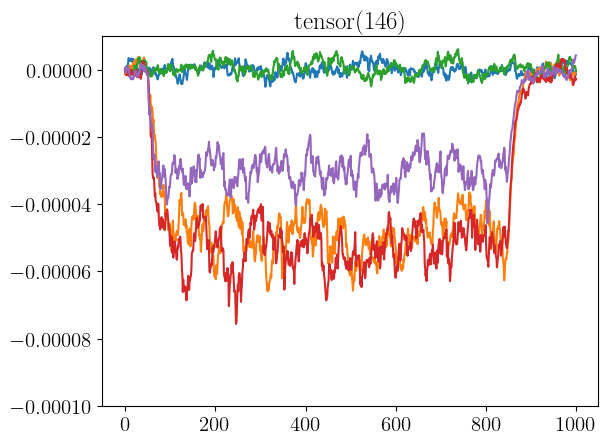

In [22]:
while True:
    trace, label = next(iter(train_loader))
    if label[0,1] == dataset_dict["odorant_idx"][14]:
        break

plt.figure()
plt.plot(trace[0].T)
plt.title(label[0,-1])
plt.ylim(-10e-5,1e-5)
plt.show()

In [2]:
with open('saved_datasets/gas_sensor_dataset/dataset_size_20_baseline_subtraction_True_data.pkl', 'rb') as f:
    dataset = dill.load(f)
with open('saved_datasets/gas_sensor_dataset/dataset_size_20_baseline_subtraction_True_labels.pkl', 'rb') as f:
    labels = dill.load(f)
    
with open('saved_datasets/gas_sensor_dataset/dataset_size_20_baseline_subtraction_False_data.pkl', 'rb') as f:
    dataset_raw = dill.load(f)

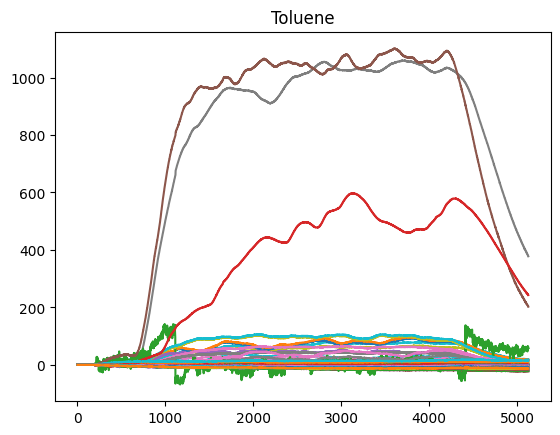

In [3]:
plt.plot(dataset[15])
plt.title(labels[15])
plt.show()

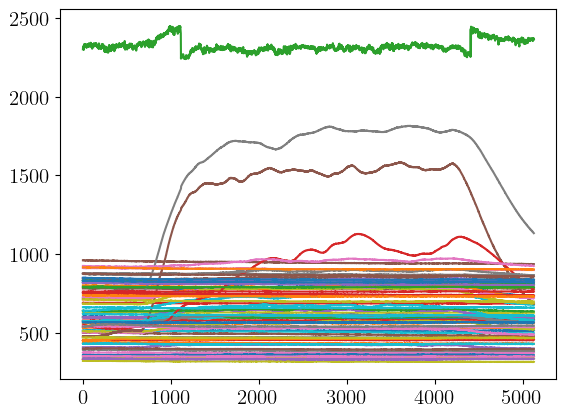

In [59]:
plt.plot(dataset_raw[15])
plt.show()

In [1]:
dataset

NameError: name 'dataset' is not defined